In [2]:
import pandas as pd

df = pd.read_csv("reduced_dataset.csv")
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,17742,200000,2,3,2,63,-1,3,2,-1,...,316,316,316,0,0,316,316,316,316,1
1,4625,240000,2,2,1,37,0,-1,-1,0,...,1932,7363,1546,1346,3195,0,7383,1546,4390,0
2,1737,80000,2,2,2,29,2,0,0,0,...,67972,66800,68693,2661,2509,2500,3000,3000,3000,1
3,28197,360000,2,2,1,40,-1,-1,-1,-1,...,41301,10889,2017,27930,692,41303,10893,2017,13894,0
4,19220,300000,2,3,1,34,-2,-2,-2,-2,...,-20,-20,4045,29089,21286,0,0,4065,0,0


In [3]:
df.shape

(4000, 25)

In [4]:
#Check dataset
print(df.shape)
print(df.columns)

(4000, 25)
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'target'],
      dtype='object')


In [21]:
#APPLY AI
results = []       # stores final labels (High/Medium/Low Risk)
risk_scores = []  # stores numeric risk score
reasons = []

for index, row in df.iterrows():
    
    risk = 0
    reason = []

    # CSP Constraints
    if row['PAY_0'] > 2:
        risk += 1
        reason.append("Late Payment")

    if row['LIMIT_BAL'] < 50000:
        risk += 1
        reason.append("Low Credit Limit")

    if row['BILL_AMT1'] > 50000:
        risk += 1
        reason.append("High Bill Amount")

    if row['PAY_AMT1'] < 1000:
        risk += 1
        reason.append("Low Payment")

    risk_scores.append(risk)

    # Decision based on constraints
    if risk >= 3:
        label = "High Risk"
    elif risk == 2:
        label = "Medium Risk"
    else:
        label = "Low Risk"

    results.append(label)

    if len(reason) == 0:
        reasons.append("Normal Behavior")
    else:
        reasons.append(", ".join(reason))

df['Risk_Score'] = risk_scores
df['AI_Result'] = results
df['Reason'] = reasons

print("AI technique : CSP Applied Successfully!")
print(df.head(10))

AI technique : CSP Applied Successfully!
      ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0  17742     200000    2          3         2   63     -1      3      2   
1   4625     240000    2          2         1   37      0     -1     -1   
2   1737      80000    2          2         2   29      2      0      0   
3  28197     360000    2          2         1   40     -1     -1     -1   
4  19220     300000    2          3         1   34     -2     -2     -2   
5   9293     140000    2          2         1   30      0      0      2   
6   8779      70000    2          2         2   24      0      0      0   
7  11520      10000    1          1         3   46      0      0      0   
8  10033     200000    1          2         2   27     -1     -1     -1   
9  11644      80000    2          1         1   34     -1      2      2   

   PAY_4  ...  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  PAY_AMT5  PAY_AMT6  \
0     -1  ...         0         0       316       316   

In [9]:
#See output summary
print("\n===== AI RESULT SUMMARY =====")
df['AI_Result'].value_counts()


===== AI RESULT SUMMARY =====


AI_Result
Low Risk       3698
Medium Risk     273
High Risk        29
Name: count, dtype: int64

In [10]:
#Compare with actual target
print("\n===== FINAL COMPARISON =====")

comparison = pd.crosstab(df['AI_Result'], df['target'])

comparison['Total'] = comparison.sum(axis=1)
comparison


===== FINAL COMPARISON =====


target,0,1,Total
AI_Result,,,
High Risk,6,23,29
Low Risk,2853,845,3698
Medium Risk,141,132,273


In [12]:
#Save final output
df.to_csv("harshitha_output.csv", index=False)

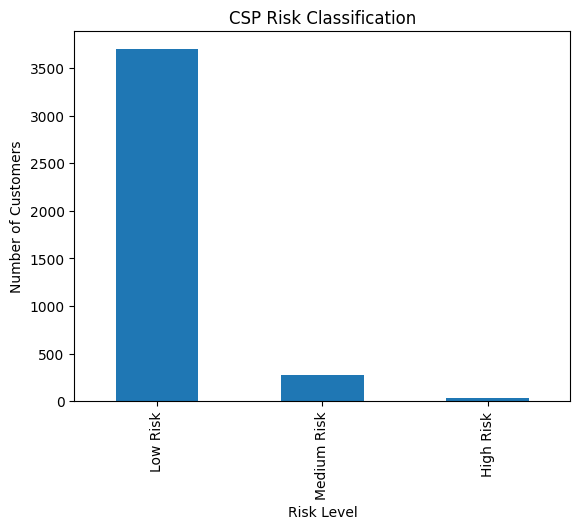

In [13]:
#graph : AI RESULT DISTRIBUTION
import matplotlib.pyplot as plt

plt.figure()
df['AI_Result'].value_counts().plot(kind='bar')

plt.title("CSP Risk Classification")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

<Figure size 640x480 with 0 Axes>

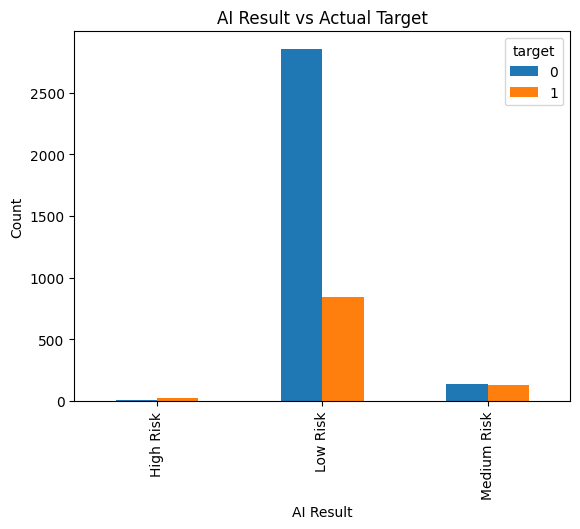

In [14]:
#ACTUAL vs AI RESULT
plt.figure()
pd.crosstab(df['AI_Result'], df['target']).plot(kind='bar')

plt.title("AI Result vs Actual Target")
plt.xlabel("AI Result")
plt.ylabel("Count")

plt.show()

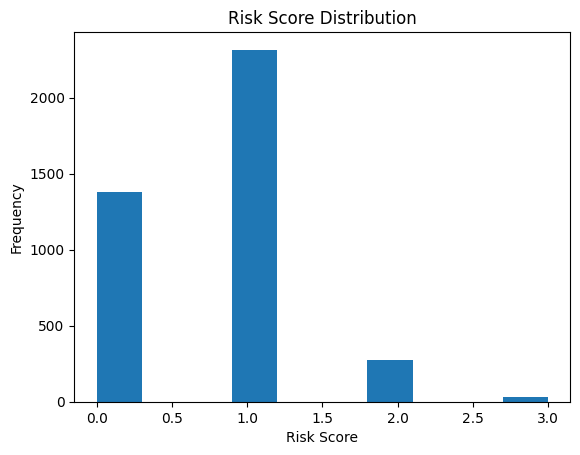

In [15]:
#RISK SCORE DISTRIBUTION
plt.figure()
df['Risk_Score'].plot(kind='hist')

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")

plt.show()

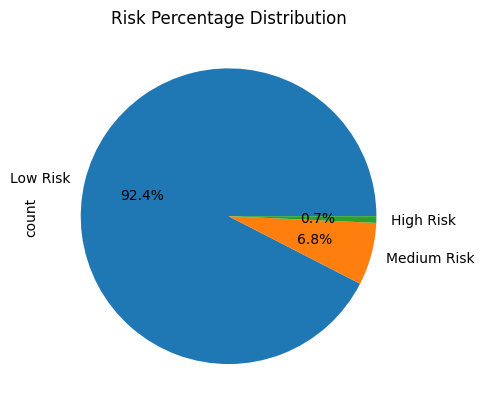

In [18]:
#piechart (percentage view)
plt.figure()
df['AI_Result'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Risk Percentage Distribution")
plt.show()

In [22]:
#USER INPUT PREDICTION
print("\n===== USER INPUT PREDICTION =====")

# Take user input
PAY_0 = int(input("Enter PAY_0 (payment delay): "))
LIMIT_BAL = int(input("Enter LIMIT_BAL (credit limit): "))
BILL_AMT1 = int(input("Enter BILL_AMT1 (bill amount): "))
PAY_AMT1 = int(input("Enter PAY_AMT1 (payment amount): "))

# Apply CSP logic
risk = 0
reason = []

if PAY_0 > 2:
    risk += 1
    reason.append("Late Payment")

if LIMIT_BAL < 50000:
    risk += 1
    reason.append("Low Credit Limit")

if BILL_AMT1 > 50000:
    risk += 1
    reason.append("High Bill Amount")

if PAY_AMT1 < 1000:
    risk += 1
    reason.append("Low Payment")

# Final decision
if risk >= 3:
    result = "High Risk"
elif risk == 2:
    result = "Medium Risk"
else:
    result = "Low Risk"

# Print output
print("\n===== PREDICTION RESULT =====")
print("Risk Score:", risk)
print("AI Result:", result)

if len(reason) == 0:
    print("Reason: Normal Behavior")
else:
    print("Reason:", ", ".join(reason))


===== USER INPUT PREDICTION =====


Enter PAY_0 (payment delay):  3
Enter LIMIT_BAL (credit limit):  40000
Enter BILL_AMT1 (bill amount):  60000
Enter PAY_AMT1 (payment amount):  500



===== PREDICTION RESULT =====
Risk Score: 4
AI Result: High Risk
Reason: Late Payment, Low Credit Limit, High Bill Amount, Low Payment


In [19]:
comparison = pd.crosstab(df['AI_Result'], df['target'])
comparison['Total'] = comparison.sum(axis=1)
comparison.loc['Total'] = comparison.sum()

comparison

target,0,1,Total
AI_Result,,,
High Risk,6,23,29
Low Risk,2853,845,3698
Medium Risk,141,132,273
Total,3000,1000,4000


In [20]:
correct = comparison.loc['Low Risk', 0] + comparison.loc['High Risk', 1]
total = comparison.loc['Total', 'Total']

accuracy = correct / total
print("Accuracy:", accuracy)

Accuracy: 0.719
